In [ ]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
import nltk
import pymorphy3
from nltk.corpus import stopwords
import seaborn as sns
import pandas as pd
from collections import Counter


In [ ]:
# Скачиваем список стоп-слов для русского языка
nltk.download("stopwords")

# Загружаем стоп-слова для русского языка в множество для быстрого поиска
russian_stopwords = set(stopwords.words("russian"))
morph = pymorphy3.MorphAnalyzer()

label_map = {
    "Genri": 0,
    "Simak": 1,
    "Bulgakov": 2,
    "Bradbury": 3,
    "Fry": 4,
    "Strugatskie": 5
}

def clean_text(text):
    """
    Очищает и нормализует текст:
    - приводит к нижнему регистру,
    - удаляет все символы, кроме букв и пробелов,
    - удаляет лишние пробелы,
    - удаляет стоп-слова,
    - приводит слова к нормальной форме (лемматизация).
    """
    text = text.lower()  # Приведение к нижнему регистру
    text = re.sub(r"[^а-яa-zё\s]", " ", text)  # Удаление всех символов, кроме букв и пробелов
    text = re.sub(r"\s+", " ", text).strip()  # Удаление лишних пробелов
    tokens = text.split()  # Токенизация (разделение на слова)
    tokens = [t for t in tokens if t not in russian_stopwords]  # Удаление стоп-слов
    # Лемматизация каждого токена
    lemmas = [morph.parse(token)[0].normal_form for token in tokens]
    return " ".join(lemmas)  # Объединение обратно в строку

def load_train_data(path):
    """
    Загружает и обрабатывает обучающие данные:
    - читает тексты авторов,
    - очищает и разбивает их на чанки по 2000 символов,
    - присваивает каждому чанку метку автора.
    """
    texts, labels = [], []
    for name, label in label_map.items():
        with open(os.path.join(path, f"{name}.txt"), encoding="utf-8") as f:
            txt = f.read()
        txt = clean_text(txt)
        chunks = [txt[i:i+2000] for i in range(0, len(txt), 2000)]
        for ch in chunks:
            if len(ch.strip()) > 100:  # Пропуск слишком коротких чанков
                texts.append(ch)
                labels.append(label)
    return texts, labels

def load_test_data(path):
    """
    Загружает и обрабатывает тестовые данные:
    - читает файлы, начинающиеся с 'author' и заканчивающиеся на '.txt',
    - очищает текст,
    - сохраняет текст и идентификатор файла.
    """
    test_texts, test_ids = [], []
    for fname in sorted(os.listdir(path)):
        if fname.startswith("author") and fname.endswith(".txt"):
            with open(os.path.join(path, fname), encoding="utf-8") as f:
                txt = f.read()
            txt = clean_text(txt)
            test_texts.append(txt.strip())
            test_ids.append(fname.replace(".txt", ""))
    return test_texts, test_ids

train_path = "writerextnd"

texts, labels = load_train_data(train_path)
test_texts, test_ids = load_test_data(train_path)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/maksimskalozubov/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


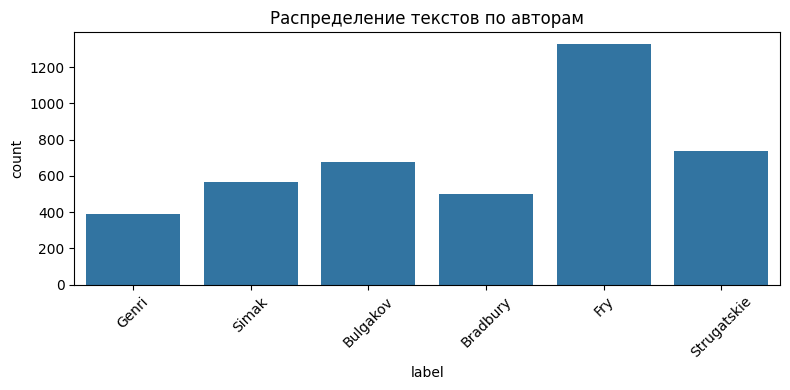

In [ ]:
# Распределение текстов по авторам
label_names = list(label_map.keys())

df = pd.DataFrame({"label": [label_names[i] for i in labels]})

plt.figure(figsize=(8, 4))

sns.countplot(x="label", data=df, order=label_names)

plt.title("Распределение текстов по авторам")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


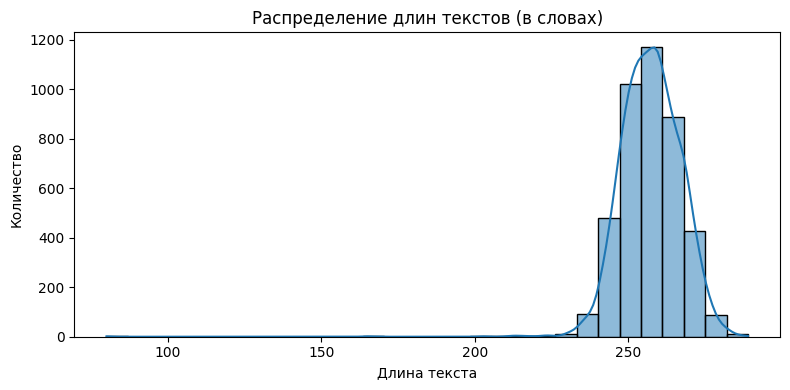

In [ ]:
# Распределение длин текстов
text_lengths = [len(t.split()) for t in texts]

plt.figure(figsize=(8, 4))
sns.histplot(text_lengths, bins=30, kde=True)
plt.title("Распределение длин текстов (в словах)")
plt.xlabel("Длина текста")
plt.ylabel("Количество")
plt.tight_layout()
plt.show()

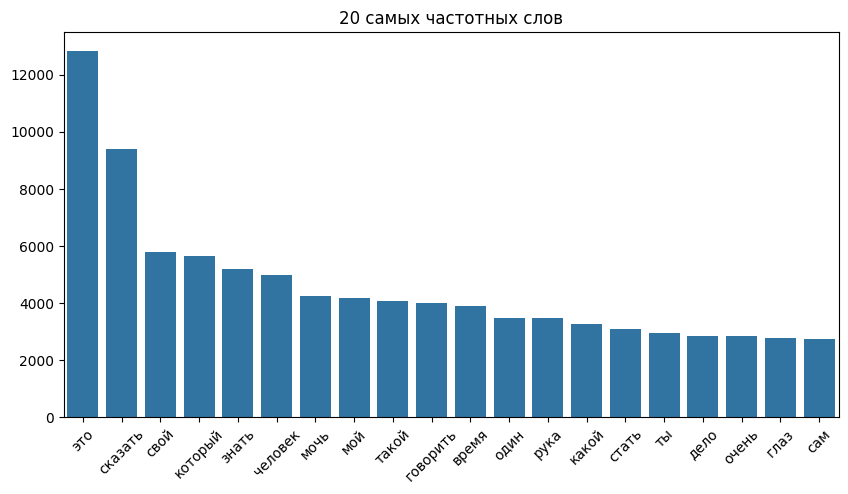

In [ ]:
# 20 самых частотных слов
all_words = " ".join(texts).split()
counter = Counter(all_words)
common_words = counter.most_common(20)

words, freqs = zip(*common_words)
plt.figure(figsize=(10,5))
sns.barplot(x=list(words), y=list(freqs))
plt.title("20 самых частотных слов")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Частотные слова
author_texts = {name: [] for name in label_map.keys()}
for text, label in zip(texts, labels):
    author = list(label_map.keys())[list(label_map.values()).index(label)]
    author_texts[author].append(text)

for author in author_texts:
    joined = " ".join(author_texts[author])
    freq = Counter(joined.split()).most_common(10)
    print(f"{author}: {[w for w, _ in freq]}")

Genri: ['сказать', 'это', 'который', 'свой', 'говорить', 'человек', 'один', 'мочь', 'знать', 'такой']
Simak: ['это', 'сказать', 'знать', 'мочь', 'человек', 'который', 'время', 'мы', 'такой', 'говорить']
Bulgakov: ['мольер', 'это', 'который', 'свой', 'человек', 'год', 'сказать', 'говорить', 'стать', 'время']
Bradbury: ['это', 'сказать', 'дуглас', 'рука', 'свой', 'знать', 'человек', 'монтэг', 'который', 'дуга']
Fry: ['это', 'мой', 'сказать', 'свой', 'знать', 'мочь', 'ты', 'который', 'такой', 'просто']
Strugatskie: ['сказать', 'это', 'андрей', 'человек', 'виктор', 'знать', 'свой', 'рука', 'такой', 'румат']


In [ ]:
# Уникальные слова
author_sets = {a: set(" ".join(author_texts[a]).split()) for a in author_texts}
for a in author_sets:
    others = set().union(*[s for k, s in author_sets.items() if k != a])
    unique = author_sets[a] - others
    print(f"Уникальные слова {a}: {list(unique)[:10]}")

Уникальные слова Genri: ['овцевод', 'капсюль', 'запальный', 'тысчонка', 'орешек', 'образцов', 'тосканский', 'вытаскив', 'смышлёность', 'виллабланк']
Уникальные слова Simak: ['вудмане', 'вселе', 'ни', 'выделка', 'макдоналд', 'молль', 'веллингтон', 'наездить', 'шутовство', 'вымуштровать']
Уникальные слова Bulgakov: ['завистниковтечь', 'василий', 'удовый', 'ал', 'демут', 'раздваиваться', 'чугункина', 'хлороформенный', 'усь', 'стегва']
Уникальные слова Bradbury: ['примешиваться', 'волнообразный', 'тить', 'занятно', 'пятипенсовый', 'скукожиться', 'засты', 'тюссо', 'пофыркивание', 'двухтонный']
Уникальные слова Fry: ['бираться', 'прилагаться', 'соул', 'бразилия', 'яв', 'ответствоваль', 'влекаться', 'мариэтта', 'ладненький', 'хайнлайна']
Уникальные слова Strugatskie: ['бама', 'натер', 'воспламенять', 'искоренить', 'вихляться', 'пединститут', 'напористо', 'скворчание', 'двенадцатибалльный', 'похохатывать']


In [ ]:
# Топ-10 слов по TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()

df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=feature_names)
df_tfidf["label"] = labels

top_words = {}
for label_id in set(labels):
    mean_tfidf = df_tfidf[df_tfidf["label"] == label_id].mean().drop("label")
    top = mean_tfidf.sort_values(ascending=False).head(10)
    top_words[label_id] = top

for label, words in top_words.items():
    print(f"{list(label_map.keys())[label]}: {list(words.index)}")

Genri: ['который', 'свой', 'сказать', 'это', 'говорить', 'мистер', 'доллар', 'гудвино', 'человек', 'деньга']
Simak: ['это', 'сказать', 'мы', 'знать', 'мочь', 'мир', 'телефон', 'человек', 'машина', 'время']
Bulgakov: ['мольер', 'пьеса', 'булгаков', 'николка', 'филипп', 'де', 'король', 'филиппович', 'турбина', 'это']
Bradbury: ['дуглас', 'монтэг', 'дуга', 'это', 'чарли', 'сказать', 'рука', 'глаз', 'дом', 'квотермейн']
Fry: ['это', 'мой', 'джуффин', 'сэр', 'ты', 'просто', 'мочь', 'знать', 'свой', 'сказать']
Strugatskie: ['андрей', 'сказать', 'виктор', 'румат', 'это', 'изя', 'дон', 'человек', 'господин', 'знать']


Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2926 - loss: 1.7890 - val_accuracy: 0.6738 - val_loss: 1.7353
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6427 - loss: 1.7131 - val_accuracy: 0.8667 - val_loss: 1.3744
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8397 - loss: 1.3580 - val_accuracy: 0.9667 - val_loss: 0.8015
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9358 - loss: 0.8009 - val_accuracy: 0.9750 - val_loss: 0.3992
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9659 - loss: 0.3940 - val_accuracy: 0.9786 - val_loss: 0.2109
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9869 - loss: 0.1876 - val_accuracy: 0.9821 - val_loss: 0.1346
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9908 - loss: 0.1090 - val_accuracy: 0.9833 - val_loss: 0.1004
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9944 - loss: 0.0699 - val_accuracy: 0.

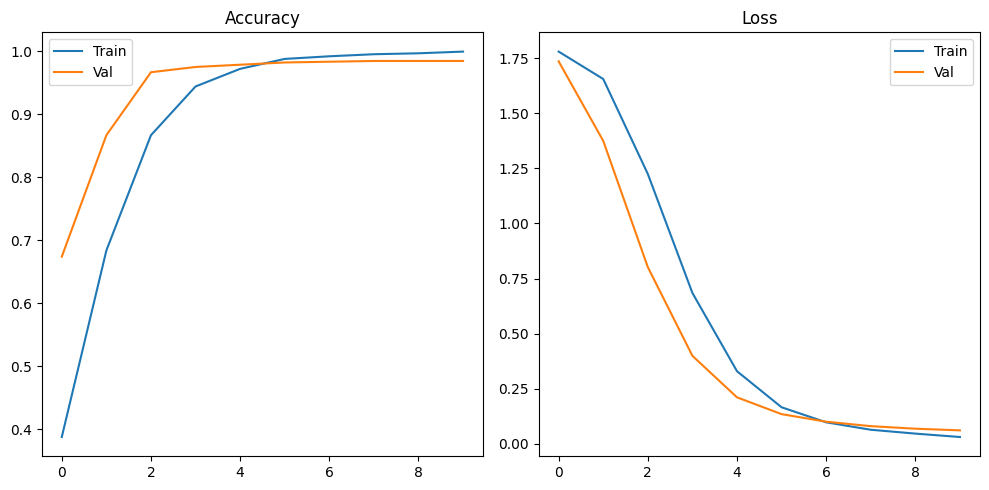

In [ ]:
# Векторизация текстов с помощью TF-IDF, учитываем униграммы и биграммы, максимум 5000 признаков
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = vectorizer.fit_transform(texts).toarray()        # Преобразуем обучающие тексты в матрицу признаков
X_test = vectorizer.transform(test_texts).toarray()  #  Преобразуем тестовые тексты в матрицу признаков
y = np.array(labels) 

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Вычисляем веса классов для балансировки
class_weights = dict(enumerate(
    compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
))

def create_tfidf_dense_model(input_dim, num_classes=6, dropout_rate=0.3):
    """
    Создаёт простую полносвязную нейронную сеть для классификации на основе TF-IDF признаков.
    - input_dim: размерность входных данных (количество признаков)
    - num_classes: количество классов (авторов)
    - dropout_rate: вероятность отключения нейронов для регуляризации
    """
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu'),
        Dropout(dropout_rate),
        Dense(128, activation='relu'),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = create_tfidf_dense_model(input_dim=X.shape[1])

# Обучаем модель
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),  
    epochs=10,                        
    batch_size=32,                    
    class_weight=class_weights 
)

preds = model.predict(X_test)
pred_labels = np.argmax(preds, axis=1)

submission = pd.DataFrame({
    "id": test_ids,
    "label": pred_labels
})
submission.to_csv("submission.csv", index=False)
print("submission.csv сохранён.")

plt.figure(figsize=(10, 5))

# График точности (accuracy) на обучении и валидации
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()

# График функции потерь (loss) на обучении и валидации
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()
